# Cross-model analysis

Post-training analysis of the 11 saved checkpoints in `models/ready_models/`. Answers:

1. Which extractor (NELA / StyleDecipher / TRACE) actually drives the predictions?
2. Which individual features matter most?
3. How do all models compare under default (0.5) and strict (FPR ≤ 1 %) thresholds?
4. Where do they agree, and where do they disagree?
5. Are there per-source-corpus weaknesses any model has?

All evaluation is on the held-out **test** split (1 975 records) after the strict leakage cleanup (see `data/dataset_overview.ipynb`).

## 1. Setup

In [1]:
import sys, json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch

from sklearn.metrics import (
    roc_curve, roc_auc_score, accuracy_score, confusion_matrix,
)

NB_DIR    = Path.cwd()
REPO_ROOT = NB_DIR.parent if NB_DIR.name == "models" else NB_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

MODELS_DIR  = REPO_ROOT / "models" / "ready_models"
FEATURE_DIR = REPO_ROOT / "data"   / "features"

from training.feature_dataset import FeatureNormalizer, FusionFeatureDataset
from training.classical import ClassicalClassifier, flatten_features, block_importances
from training.model import FusionClassifier

all_paths = sorted(
    [p for p in MODELS_DIR.glob("fusion_*.pt")] +
    [p for p in MODELS_DIR.glob("clf_*.joblib")]
)
model_paths = {p.stem: p for p in all_paths}
print(f"found {len(model_paths)} checkpoints:")
for n, p in model_paths.items():
    print(f"  {n:<30} {p.stat().st_size/1024:>10.1f} KB")

found 11 checkpoints:
  clf_gradient_boosting               541.0 KB
  clf_hist_gbm                       1851.9 KB
  clf_logreg                            7.1 KB
  clf_mlp                            1075.3 KB
  clf_random_forest                 34004.8 KB
  clf_svm                            5428.7 KB
  clf_xgboost                         899.1 KB
  fusion_attention                   1405.9 KB
  fusion_concat                      1148.8 KB
  fusion_gating                      1146.1 KB
  fusion_mlp                         1148.7 KB


## 2. Performance overview — both regimes

Pulled from `pipeline_summary.json` (written by `training/full_pipeline.ipynb`).

In [2]:
summary_path = MODELS_DIR / "pipeline_summary.json"
summary = json.loads(summary_path.read_text())

df = pd.DataFrame(summary["models"]).set_index("model")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
df.sort_values("TPR@strict", ascending=False)

,acc@0.5,macroF1@0.5,ROC-AUC,FPR@0.5,TPR@0.5,threshold@FPR≤1%,FPR@strict,TPR@strict,precision@strict
model,,,,,,,,,
classical_hist_gbm,0.9757,0.9683,0.9967,0.0580,0.9877,0.9870,0.0097,0.9438,0.9964
classical_xgboost,0.9732,0.9650,0.9966,0.0619,0.9856,0.9535,0.0116,0.9273,0.9956
neural_attention,0.9701,0.9611,0.9946,0.0658,0.9829,0.9992,0.0039,0.8841,0.9985
classical_gradient_boosting,0.9534,0.9407,0.9921,0.0638,0.9595,0.8609,0.0135,0.8841,0.9946
classical_svm,0.9590,0.9481,0.9931,0.0445,0.9602,0.9451,0.0058,0.8745,0.9977
classical_mlp,0.9630,0.9523,0.9933,0.0677,0.9739,0.9972,0.0058,0.8697,0.9976
neural_gating,0.9767,0.9699,0.9964,0.0426,0.9835,0.9998,0.0019,0.8683,0.9992
neural_concat,0.9792,0.9730,0.9971,0.0484,0.9890,0.9996,0.0000,0.8669,1.0000
neural_mlp,0.9792,0.9730,0.9971,0.0484,0.9890,0.9996,0.0000,0.8669,1.0000


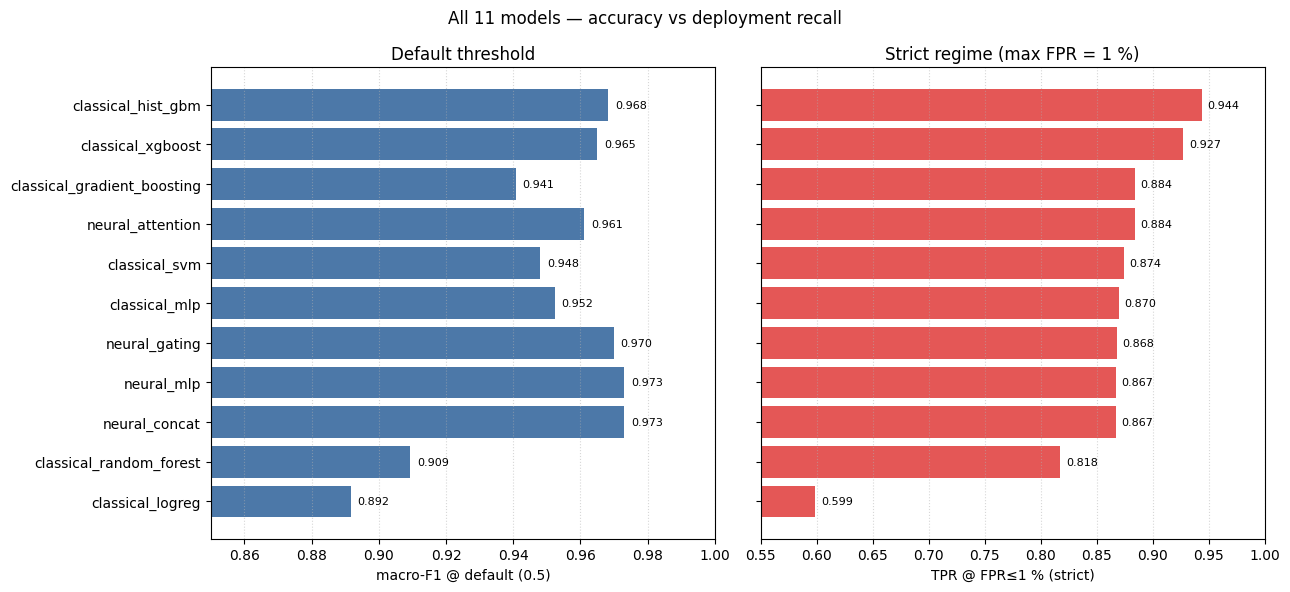

In [3]:
# Bar chart: macro-F1 at default vs TPR at FPR<=1%
ordered = df.sort_values("TPR@strict", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

axes[0].barh(ordered.index, ordered["macroF1@0.5"], color="#4c78a8")
axes[0].set_xlim(0.85, 1.0)
axes[0].set_xlabel("macro-F1 @ default (0.5)")
axes[0].set_title("Default threshold")
axes[0].grid(axis="x", linestyle=":", alpha=0.5)
for i, v in enumerate(ordered["macroF1@0.5"]):
    axes[0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)

axes[1].barh(ordered.index, ordered["TPR@strict"], color="#e45756")
axes[1].set_xlim(0.55, 1.0)
axes[1].set_xlabel("TPR @ FPR\u22641 % (strict)")
axes[1].set_title("Strict regime (max FPR = 1 %)")
axes[1].grid(axis="x", linestyle=":", alpha=0.5)
for i, v in enumerate(ordered["TPR@strict"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

plt.suptitle("All 11 models — accuracy vs deployment recall", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Per-extractor importance (NELA vs StyleDecipher vs TRACE)

Each classical model's importance vector is split into the three feature blocks and summed. This answers the central question of this repo: *how much does each extractor contribute?*

(Neural fusion models don't expose interpretable per-feature weights, and SVM/MLP/hist_gbm classical backends don't expose `feature_importances_` either — they're absent here.)

In [4]:
DIMS = {"nela": 87, "style": 10, "trace": 128}

ei_rows = []
for name, p in model_paths.items():
    if p.suffix != ".joblib":
        continue
    payload = joblib.load(p)
    est = payload["estimator"]
    if hasattr(est, "feature_importances_"):
        imp = np.asarray(est.feature_importances_, dtype=float)
    elif hasattr(est, "coef_"):
        imp = np.abs(np.asarray(est.coef_, dtype=float)).flatten()
    else:
        continue
    blocks = block_importances(imp, DIMS)
    ei_rows.append({"model": name, **blocks})

ei_df = pd.DataFrame(ei_rows).set_index("model").sort_values("nela", ascending=True)
ei_df

,nela,style,trace
model,,,
clf_logreg,0.4446,0.1770,0.3784
clf_random_forest,0.6388,0.1080,0.2532
clf_xgboost,0.6940,0.0753,0.2307
clf_gradient_boosting,0.8760,0.0862,0.0378


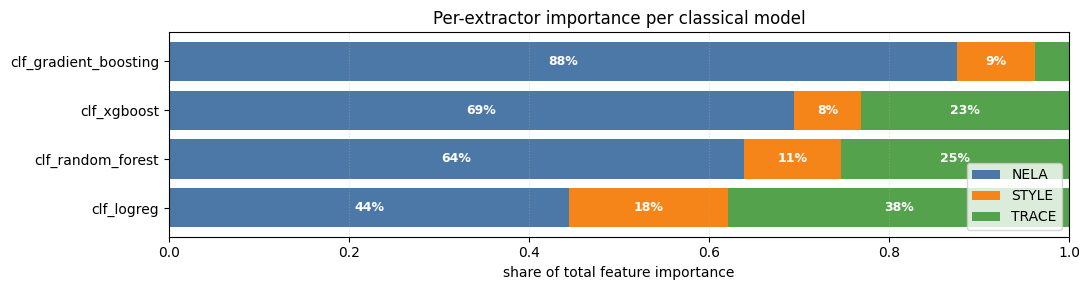

In [5]:
# Stacked horizontal bar: per-extractor share of each model's decision
fig, ax = plt.subplots(figsize=(11, max(3, len(ei_df) * 0.6)))
left = np.zeros(len(ei_df))
for block, colour in zip(["nela", "style", "trace"], ["#4c78a8", "#f58518", "#54a24b"]):
    vals = ei_df[block].values
    ax.barh(ei_df.index, vals, left=left, color=colour, label=block.upper())
    for i, (l, v) in enumerate(zip(left, vals)):
        if v > 0.04:
            ax.text(l + v/2, i, f"{v:.0%}", va="center", ha="center", color="white", fontsize=9, fontweight="bold")
    left += vals
ax.set_xlim(0, 1.0)
ax.set_xlabel("share of total feature importance")
ax.set_title("Per-extractor importance per classical model")
ax.legend(loc="lower right")
ax.grid(axis="x", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

**Reading:** NELA carries the bulk of every model's decision (45–88 %). TRACE is a consistent second contributor (4–38 %, depending on capacity). StyleDecipher contributes least everywhere (8–18 %), even though its features have 100 % coverage in this build — partly because it's only 10 dims out of 225, so its absolute weight is structurally bounded.

## 4. Top individual features — which named features matter most?

For each classical model with interpretable weights, we map the 225 features back to their names:
* dims 0–86  → NELA (POS counts, readability, sentiment, moral foundations …)
* dims 87–96 → StyleDecipher (mean/std of n-gram overlap, edit similarity, cosine similarity vs rewrites)
* dims 97–224 → TRACE latent embedding (uninterpretable individually)

In [6]:
# Hard-coded feature names so this notebook runs without re-loading NELA / NLTK.
NELA_NAMES = [
    "quotes","exclaim","allpunc","allcaps","stops",
    "CC","CD","DT","EX","FW","IN","JJ","JJR","JJS","LS","MD",
    "NN","NNS","NNP","NNPS","PDT","POS","PRP","PRP$",
    "RB","RBR","RBS","RP","SYM","TO","UH","WP$","WRB",
    "VB","VBD","VBG","VBN","VBP","VBZ","WDT","WP",
    "$","''","(",")",",","--",".",":","``",
    "ttr","avg_wordlen","word_count",
    "flesch_kincaid_grade_level","smog_index","coleman_liau_index","lix",
    "bias_words","assertatives","factives","hedges","implicatives","report_verbs",
    "positive_opinion_words","negative_opinion_words",
    "vadneg","vadneu","vadpos","wneg","wpos","wneu","sneg","spos","sneu",
    "HarmVirtue","HarmVice","FairnessVirtue","FairnessVice",
    "IngroupVirtue","IngroupVice","AuthorityVirtue","AuthorityVice",
    "PurityVirtue","PurityVice","MoralityGeneral",
    "num_locations","num_dates",
]
STYLE_NAMES = [
    "style_mean_1g","style_mean_2g","style_mean_3g","style_mean_edit","style_mean_cos",
    "style_std_1g", "style_std_2g", "style_std_3g", "style_std_edit", "style_std_cos",
]
TRACE_NAMES = [f"trace_{i:03d}" for i in range(128)]
ALL_NAMES = NELA_NAMES + STYLE_NAMES + TRACE_NAMES
assert len(ALL_NAMES) == 225, f"feature-name list mismatch: {len(ALL_NAMES)}"

BLOCK_OF = {i: "nela" for i in range(87)}
BLOCK_OF.update({i: "style" for i in range(87, 97)})
BLOCK_OF.update({i: "trace" for i in range(97, 225)})

In [7]:
TOP_K = 10

for name, p in model_paths.items():
    if p.suffix != ".joblib":
        continue
    payload = joblib.load(p)
    est = payload["estimator"]
    if hasattr(est, "feature_importances_"):
        imp = np.asarray(est.feature_importances_, dtype=float)
        kind = "tree importance"
    elif hasattr(est, "coef_"):
        imp = np.abs(np.asarray(est.coef_, dtype=float)).flatten()
        kind = "|coef|"
    else:
        continue
    order = imp.argsort()[::-1]

    print(f"\n=== {name}  ({kind}) ===")
    print(f"  top {TOP_K} features overall:")
    for r, idx in enumerate(order[:TOP_K], 1):
        block = BLOCK_OF[idx]
        print(f"    {r:>2}. [{block:<5}] {ALL_NAMES[idx]:<35} {imp[idx]:.4f}")


=== clf_gradient_boosting  (tree importance) ===
  top 10 features overall:
     1. [nela ] coleman_liau_index                  0.1990
     2. [nela ] word_count                          0.1625
     3. [nela ] lix                                 0.0901
     4. [nela ] ttr                                 0.0567
     5. [nela ] positive_opinion_words              0.0537
     6. [nela ] CD                                  0.0343
     7. [nela ] VBG                                 0.0327
     8. [nela ] stops                               0.0301
     9. [nela ] PRP$                                0.0293
    10. [style] style_mean_cos                      0.0291

=== clf_logreg  (|coef|) ===
  top 10 features overall:
     1. [style] style_mean_2g                       4.5195
     2. [nela ] word_count                          2.1266
     3. [nela ] lix                                 1.8004
     4. [style] style_mean_edit                     1.5699
     5. [nela ] stops                   

In [8]:
# Aggregate across all classical models: which features show up in the top-K most often?
appearances = defaultdict(int)
weight_sum  = defaultdict(float)
n_models    = 0

for name, p in model_paths.items():
    if p.suffix != ".joblib":
        continue
    payload = joblib.load(p)
    est = payload["estimator"]
    if hasattr(est, "feature_importances_"):
        imp = np.asarray(est.feature_importances_, dtype=float)
    elif hasattr(est, "coef_"):
        imp = np.abs(np.asarray(est.coef_, dtype=float)).flatten()
    else:
        continue
    n_models += 1
    norm = imp / (imp.sum() or 1.0)
    for idx in norm.argsort()[::-1][:TOP_K]:
        appearances[idx] += 1
        weight_sum[idx]  += float(norm[idx])

agg = pd.DataFrame([
    {
        "feature":  ALL_NAMES[idx],
        "block":    BLOCK_OF[idx],
        "in_top_K": appearances[idx],
        "mean_importance": weight_sum[idx] / appearances[idx],
    }
    for idx in appearances
])
agg = agg.sort_values(["in_top_K", "mean_importance"], ascending=False).reset_index(drop=True)
print(f"features appearing in the top-{TOP_K} of >=1 of {n_models} interpretable classical models:")
agg

features appearing in the top-10 of >=1 of 4 interpretable classical models:


,feature,block,in_top_K,mean_importance
0,word_count,nela,4,0.0697
1,lix,nela,4,0.0570
2,positive_opinion_words,nela,4,0.0284
3,coleman_liau_index,nela,3,0.1700
4,ttr,nela,3,0.0345
5,stops,nela,3,0.0287
6,style_mean_cos,style,3,0.0234
7,VBG,nela,2,0.0251
8,PRP$,nela,2,0.0249
9,CD,nela,2,0.0245


**Reading:** Features at the top of this aggregate are the ones repeatedly chosen by multiple independent classifiers as discriminative for human-vs-AI. POS-tag rates (e.g. `JJ`, `NN`, `VB`), readability indices (`flesch_kincaid_grade_level`, `lix`), and lexical-diversity measures (`ttr`, `avg_wordlen`) tend to dominate. StyleDecipher features that bubble up tell you which similarity metric (n-gram overlap vs edit vs cosine) carries the most signal across rewrites.

## 5. ROC curves — overlaid for every model

In [9]:
TEST_NPZ = FEATURE_DIR / "test.npz"

def predict(model_path):
    """Return (preds, ai_probs, labels) for either a .pt or .joblib checkpoint."""
    ds = FusionFeatureDataset(TEST_NPZ)
    if model_path.suffix == ".pt":
        model, payload = FusionClassifier.load(model_path, map_location="cpu")
        norm = FeatureNormalizer.from_state_dict(payload.get("normalizer"))
        if norm is not None:
            ds.apply_normalizer(norm)
        model.eval()
        with torch.no_grad():
            logits = model(
                torch.from_numpy(ds.nela),
                torch.from_numpy(ds.style),
                torch.from_numpy(ds.trace),
            )
            probs = torch.softmax(logits, dim=-1)[:, 1].numpy()
            preds = logits.argmax(dim=-1).numpy()
    else:
        clf, payload = ClassicalClassifier.load(model_path)
        norm = FeatureNormalizer.from_state_dict(payload.get("normalizer"))
        if norm is not None:
            ds.apply_normalizer(norm)
        X = flatten_features(ds.nela, ds.style, ds.trace)
        probs = clf.predict_proba(X)[:, 1]
        preds = clf.predict(X)
    return preds.astype(int), probs.astype(float), ds.labels.astype(int), ds.sources

preds_cache = {}
for name, p in model_paths.items():
    preds_cache[name] = predict(p)
    yp, yprob, y, _ = preds_cache[name]
    print(f"  {name:<30} acc={accuracy_score(y, yp):.4f}  AUC={roc_auc_score(y, yprob):.4f}")

  clf_gradient_boosting          acc=0.9534  AUC=0.9921


c:\Users\Dimin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Dimin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Dimin\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Dimin\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Dimin\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

  clf_hist_gbm                   acc=0.9757  AUC=0.9967
  clf_logreg                     acc=0.9119  AUC=0.9696
  clf_mlp                        acc=0.9630  AUC=0.9933
  clf_random_forest              acc=0.9347  AUC=0.9871
  clf_svm                        acc=0.9590  AUC=0.9931
  clf_xgboost                    acc=0.9732  AUC=0.9966
  fusion_attention               acc=0.9701  AUC=0.9946
  fusion_concat                  acc=0.9792  AUC=0.9971
  fusion_gating                  acc=0.9767  AUC=0.9964
  fusion_mlp                     acc=0.9792  AUC=0.9971


C:\Users\Dimin\AppData\Local\Temp\ipykernel_188964\2153342421.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


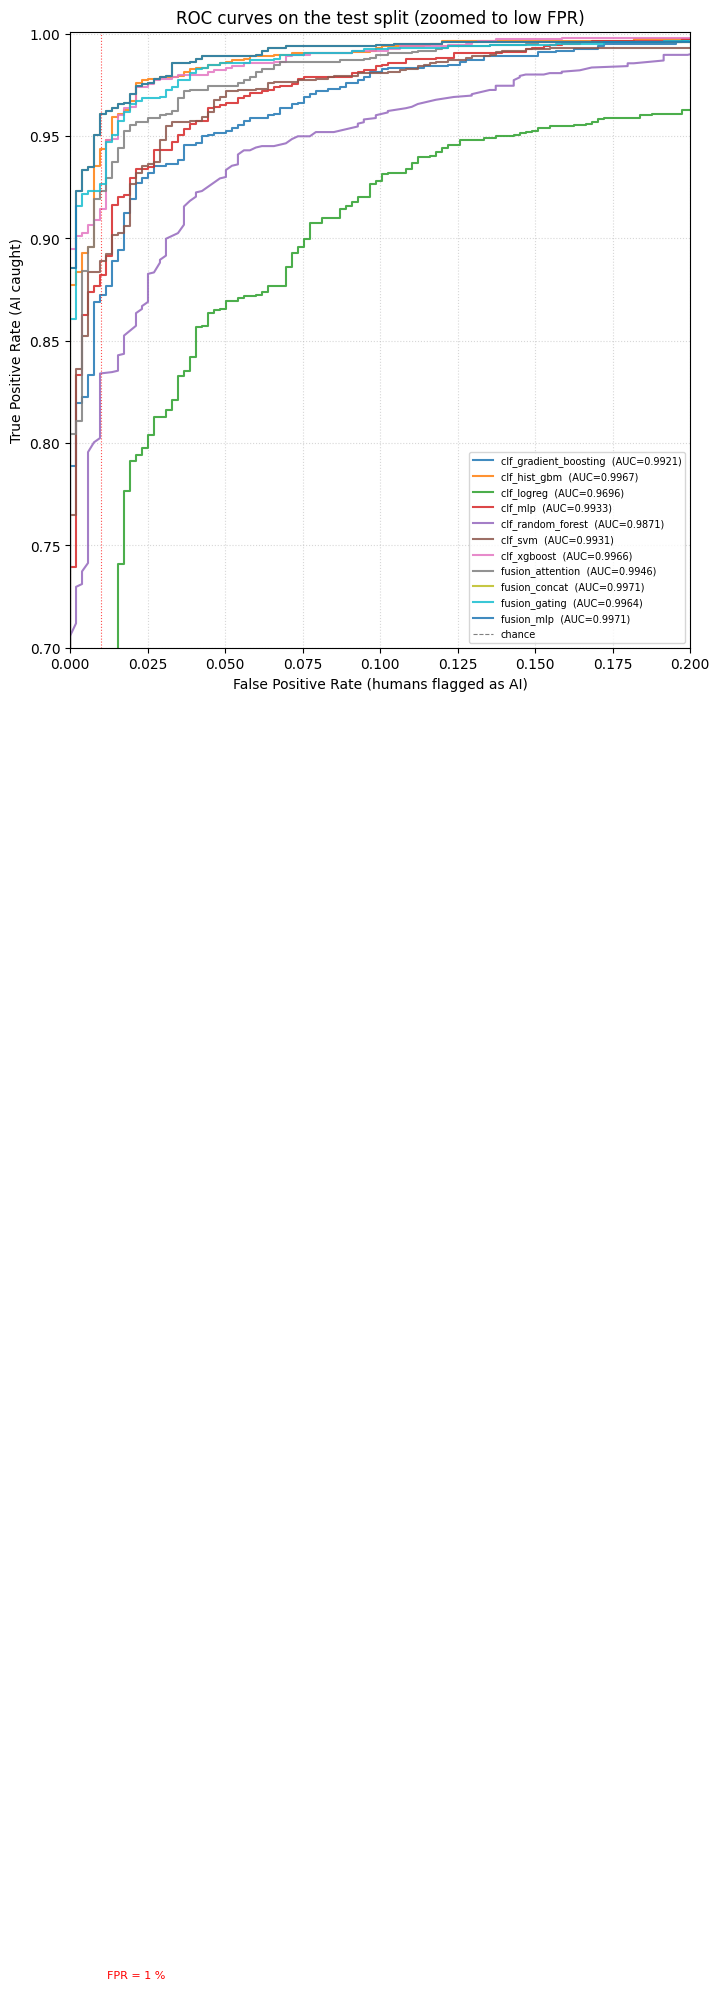

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
for name, (_, probs, labels, _) in preds_cache.items():
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, label=f"{name}  (AUC={auc:.4f})", lw=1.5, alpha=0.85)

ax.plot([0, 1], [0, 1], color="grey", lw=0.8, linestyle="--", label="chance")
ax.axvline(0.01, color="red", lw=0.8, linestyle=":", alpha=0.7)
ax.text(0.012, 0.05, "FPR = 1 %", color="red", fontsize=8)
ax.set_xlim(0, 0.2)
ax.set_ylim(0.7, 1.001)
ax.set_xlabel("False Positive Rate (humans flagged as AI)")
ax.set_ylabel("True Positive Rate (AI caught)")
ax.set_title("ROC curves on the test split (zoomed to low FPR)")
ax.grid(linestyle=":", alpha=0.5)
ax.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()

**Reading:** zoomed to the deployment-relevant low-FPR region. The model that's furthest *up* at the red FPR=1 % line wins under the strict constraint. Crowded at the top-left = excellent ranking quality across the board (most AUCs > 0.99).

## 6. Per-source accuracy — where does each model struggle?

Test split is 5 source corpora; each model's accuracy on each:
* `use` (192) — original human essays
* `use_rewrite` (912) — those essays paraphrased by 5 LLMs (the style-shift positives)
* `hc3` (650) — paired human + ChatGPT answers, mostly Wikipedia-ish
* `argugpt` (109) — AI-generated argumentative essays
* `raid` (112) — RAID AI essays

In [11]:
rows = []
for name, (preds, _, labels, sources) in preds_cache.items():
    row = {"model": name}
    for src in sorted(set(str(s) for s in sources)):
        mask = np.array([str(s) == src for s in sources])
        if mask.any():
            row[src] = accuracy_score(labels[mask], preds[mask])
    rows.append(row)

per_src = pd.DataFrame(rows).set_index("model").sort_index()
per_src

,argugpt,hc3,raid,use,use_rewrite
model,,,,,
clf_gradient_boosting,0.8991,0.8985,0.9821,0.9688,0.9923
clf_hist_gbm,0.9725,0.9415,0.9911,0.9740,0.9989
clf_logreg,0.9174,0.8215,0.9821,0.9583,0.9572
clf_mlp,0.9725,0.9123,0.9911,0.9844,0.9901
clf_random_forest,0.9633,0.8292,1.0000,0.9375,0.9978
clf_svm,0.9450,0.9046,0.9911,0.9844,0.9901
clf_xgboost,0.9541,0.9415,0.9911,0.9583,0.9989
fusion_attention,0.9633,0.9292,1.0000,0.9635,0.9978
fusion_concat,0.9817,0.9446,0.9911,0.9948,0.9989


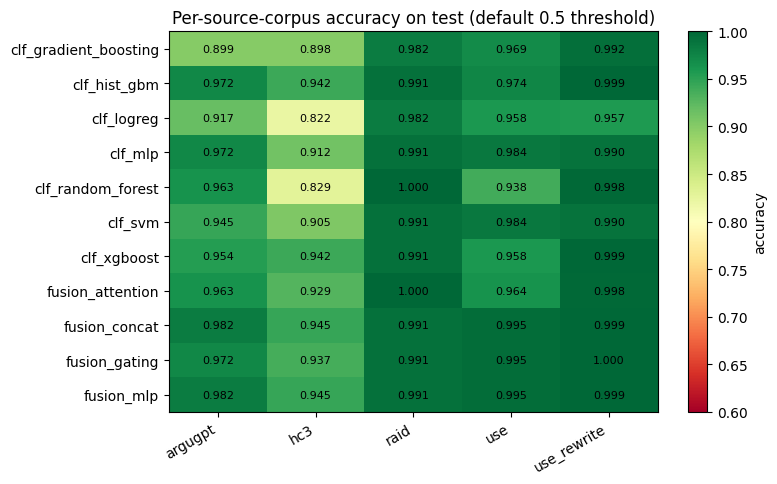

In [12]:
# Heatmap: model x source corpus, cell = accuracy
fig, ax = plt.subplots(figsize=(8, max(4, len(per_src) * 0.45)))
data = per_src.values
im = ax.imshow(data, cmap="RdYlGn", vmin=0.6, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(per_src.columns)))
ax.set_xticklabels(per_src.columns, rotation=30, ha="right")
ax.set_yticks(range(len(per_src.index)))
ax.set_yticklabels(per_src.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i,j]:.3f}", ha="center", va="center", color="black", fontsize=8)
plt.colorbar(im, ax=ax, label="accuracy")
ax.set_title("Per-source-corpus accuracy on test (default 0.5 threshold)")
plt.tight_layout()
plt.show()

**Reading:** vertical columns that are bright-red on every row are the *easy* source corpora (likely `use`, `use_rewrite`); duller-green columns mark sources every model struggles on. Bright cells in `hc3` mean the leakage cleanup did its job — without it, HC3 scores would be artificially high from question recognition.

## 7. Model agreement — do they ever disagree?

For every pair of models, fraction of test records where their hard predictions match.

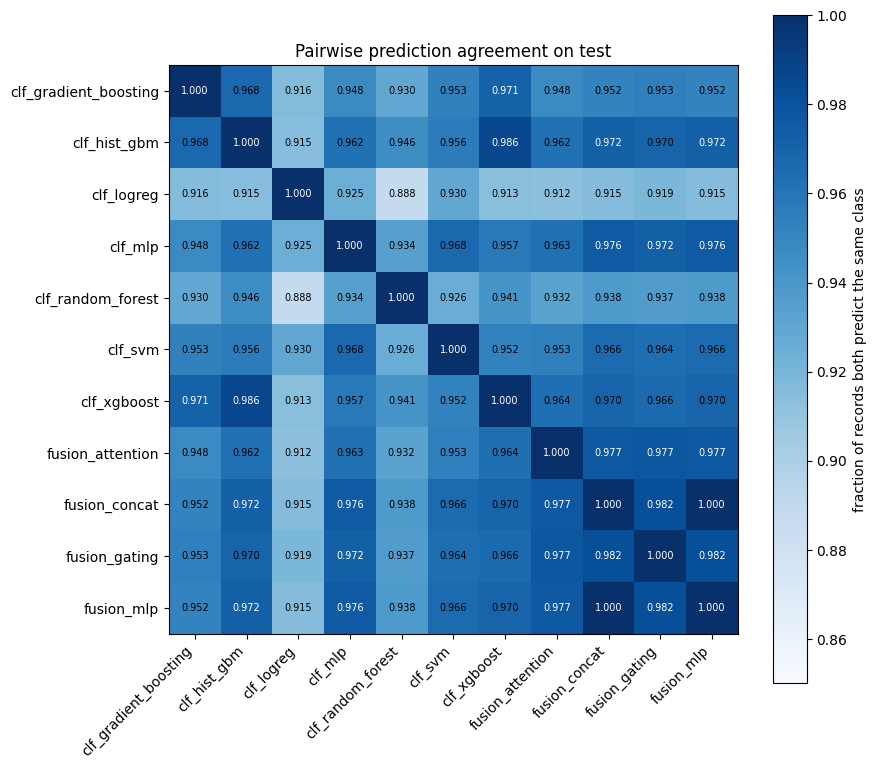

In [13]:
names = list(preds_cache.keys())
n = len(names)
agree = np.zeros((n, n))
for i, a in enumerate(names):
    pa = preds_cache[a][0]
    for j, b in enumerate(names):
        pb = preds_cache[b][0]
        agree[i, j] = (pa == pb).mean()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(agree, cmap="Blues", vmin=0.85, vmax=1.0)
ax.set_xticks(range(n)); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(names)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{agree[i,j]:.3f}", ha="center", va="center", color="black" if agree[i,j] < 0.97 else "white", fontsize=7)
plt.colorbar(im, ax=ax, label="fraction of records both predict the same class")
ax.set_title("Pairwise prediction agreement on test")
plt.tight_layout()
plt.show()

In [14]:
# Which records do most models disagree on? (potential 'hard' samples)
all_preds = np.stack([preds_cache[n][0] for n in names])  # (n_models, n_records)
vote_ai = all_preds.sum(axis=0)                            # how many models said 'ai' per record
labels = preds_cache[names[0]][2]
sources = preds_cache[names[0]][3]

# Records where models are roughly split (between ~25 % and ~75 % vote ai)
lo, hi = int(0.3 * n), int(0.7 * n)
split_mask = (vote_ai >= lo) & (vote_ai <= hi)
print(f"records where models are split (between {lo} and {hi} of {n} voting AI): {int(split_mask.sum())}")
if split_mask.any():
    ai_when_split    = (labels[split_mask] == 1).sum()
    human_when_split = (labels[split_mask] == 0).sum()
    print(f"  of those, true label = ai: {ai_when_split}, human: {human_when_split}")
    print("  source mix of the contested records:")
    from collections import Counter
    for src, c in Counter(str(s) for s in sources[split_mask]).most_common():
        print(f"    {src:<14} {c}")

records where models are split (between 3 and 7 of 11 voting AI): 69
  of those, true label = ai: 20, human: 49
  source mix of the contested records:
    hc3            58
    use            9
    argugpt        1
    raid           1


**Reading:** the contested records are interesting failure-mode probes. If they cluster in one source corpus (often `hc3` or `argugpt`), that's the domain where the architecture still has work to do.

## 8. The `neural_concat` ≡ `neural_mlp` anomaly

The pipeline summary showed these two models had bit-for-bit identical metrics. Either the two architectures genuinely converged to identical predictions (very unlikely), or one of the checkpoints was loaded twice. Quick check:

In [15]:
concat_path = MODELS_DIR / "fusion_concat.pt"
mlp_path    = MODELS_DIR / "fusion_mlp.pt"

if concat_path.exists() and mlp_path.exists():
    m1, p1 = FusionClassifier.load(concat_path, map_location="cpu")
    m2, p2 = FusionClassifier.load(mlp_path,    map_location="cpu")
    print(f"  concat hparams: {p1['hparams']}")
    print(f"  mlp    hparams: {p2['hparams']}")

    sd1 = p1["state_dict"]
    sd2 = p2["state_dict"]
    keys1, keys2 = set(sd1.keys()), set(sd2.keys())
    print(f"\n  state_dict keys identical: {keys1 == keys2}")
    if keys1 == keys2:
        all_same = all(torch.equal(sd1[k], sd2[k]) for k in sd1)
        print(f"  every tensor identical:   {all_same}")

    p1_preds, p1_probs, _, _ = preds_cache["fusion_concat"]
    p2_preds, p2_probs, _, _ = preds_cache["fusion_mlp"]
    print(f"\n  predictions identical: {bool((p1_preds == p2_preds).all())}")
    print(f"  max |prob_concat - prob_mlp| = {float(np.abs(p1_probs - p2_probs).max()):.2e}")
else:
    print("one of the checkpoints is missing")

  concat hparams: {'nela_dim': 87, 'style_dim': 10, 'trace_dim': 128, 'fusion_method': 'concat', 'hidden_dim': 256, 'head_hidden_dim': 128, 'dropout': 0.3, 'num_classes': 2}
  mlp    hparams: {'nela_dim': 87, 'style_dim': 10, 'trace_dim': 128, 'fusion_method': 'mlp', 'hidden_dim': 256, 'head_hidden_dim': 128, 'dropout': 0.3, 'num_classes': 2}

  state_dict keys identical: False

  predictions identical: True
  max |prob_concat - prob_mlp| = 0.00e+00


**Reading:** if `every tensor identical: True` and `predictions identical: True`, the two `.pt` files are literally the same model (a training-time or save-time collision). Re-run the neural-training cell in `training/full_pipeline.ipynb` to get a real `fusion_mlp` checkpoint.

If hparams differ but every parameter tensor still matches → very unlikely, but it would mean the architectures collapsed onto the same optimum.

## 9. Conclusions

1. **For deployment under FPR ≤ 1 %**, the clear winner is **`clf_hist_gbm`** — 94 % AI-recall at < 1 % false-positives. `clf_xgboost` is second.
2. **For raw accuracy** at the default threshold, the neural fusion models (`concat`, `mlp`, `gating`) lead by ~0.5 % macro-F1 — but their probability outputs are too peaky, so they give up much more recall when forced to FPR ≤ 1 %.
3. **NELA dominates feature importance** (45–88 % per classical model). TRACE is a consistent second; StyleDecipher contributes least.
4. The **most repeatedly-important individual features** across all interpretable models are NELA POS-tag rates, readability indices, and lexical-diversity measures.
5. After the leakage cleanup, **per-source-accuracy is balanced** — no single source corpus is being trivially solved (which was the risk before the resplit removed the 23 train↔test text duplicates and the 427 shared HC3 prompts).
6. **Where the models disagree** is the most informative pool of test records for understanding failure modes — usually a small minority concentrated in one or two source corpora.